In [ ]:
import os
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

BASE        = Path("/content/drive/MyDrive/Machine Learning Class Project/Colab Notebooks")
CACHE_DIR   = BASE / "cache"
NESO_PATH   = BASE / "neso_historic_generation_mix.csv"

print("BASE:", BASE)
print("CACHE_DIR:", CACHE_DIR)
print("NESO_PATH:", NESO_PATH)
print("Cache contents:", [f.name for f in sorted(CACHE_DIR.iterdir())])

Mounted at /content/drive
BASE: /content/drive/MyDrive/Machine Learning Class Project/Colab Notebooks
CACHE_DIR: /content/drive/MyDrive/Machine Learning Class Project/Colab Notebooks/cache
NESO_PATH: /content/drive/MyDrive/Machine Learning Class Project/Colab Notebooks/neso_historic_generation_mix.csv
Cache contents: ['features_sample500.parquet', 'lgbm_hh.txt', 'lgbm_hh_features.json', 'lstm_hh.keras', 'lstm_hh_features.json']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import json
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [ ]:
# Load the LightGBM model
lgb_model = lgb.Booster(model_file=str(CACHE_DIR / "lgbm_hh.txt"))

# Load the feature metadata
with open(CACHE_DIR / "lgbm_hh_features.json") as f:
    feat_meta = json.load(f)

print("Feature metadata:")
print(json.dumps(feat_meta, indent=2))

Feature metadata:
{
  "num": [
    "temperature",
    "apparentTemperature",
    "humidity",
    "windSpeed",
    "pressure",
    "dewPoint",
    "visibility",
    "hdd",
    "cdd",
    "is_holiday",
    "is_weekend",
    "hour",
    "half_hour",
    "dow",
    "month",
    "lag_1",
    "lag_2",
    "lag_48",
    "lag_336",
    "rolling_mean_1d",
    "rolling_std_1d",
    "rolling_mean_7d",
    "rolling_std_7d",
    "household_train_mean"
  ],
  "cat": [
    "Acorn",
    "Acorn_grouped",
    "stdorToU",
    "icon",
    "precipType"
  ],
  "best_iteration": 5992
}


In [ ]:
df_feat = pd.read_parquet(CACHE_DIR / "features_sample500.parquet")

print("Shape:", df_feat.shape)
print("Columns:", df_feat.columns.tolist())
print("Date range:", df_feat["tstp"].min(), "→", df_feat["tstp"].max())
print(df_feat.head(3))

Shape: (14677119, 36)
Columns: ['LCLid', 'tstp', 'energy', 'temperature', 'apparentTemperature', 'humidity', 'windSpeed', 'pressure', 'dewPoint', 'visibility', 'icon', 'precipType', 'hdd', 'cdd', 'Acorn', 'Acorn_grouped', 'stdorToU', 'is_holiday', 'household_train_mean', 'hour', 'half_hour', 'dow', 'month', 'is_weekend', 'hh_sin', 'hh_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_2', 'lag_48', 'lag_336', 'rolling_mean_1d', 'rolling_std_1d', 'rolling_mean_7d', 'rolling_std_7d']
Date range: 2011-12-01 00:00:00 → 2014-02-27 23:30:00
       LCLid                tstp  energy  temperature  apparentTemperature  \
0  MAC000053 2011-12-17 00:00:00   0.259         2.88                -0.49   
1  MAC000053 2011-12-17 00:30:00   0.409         2.88                -0.49   
2  MAC000053 2011-12-17 01:00:00   0.176         2.81                -0.58   

   humidity  windSpeed    pressure  dewPoint  visibility  ...   dow_sin  \
0      0.86       3.60  1002.27002      0.83       11.25  ... -0.974928   
1    

In [ ]:
# Recreate the same temporal split
train_cutoff = df_feat["tstp"].quantile(0.70)
val_cutoff   = df_feat["tstp"].quantile(0.85)

test_mask = df_feat["tstp"] >= val_cutoff
df_test = df_feat[test_mask].copy().reset_index(drop=True)

print(f"Test rows: {len(df_test):,}")
print(f"Test range: {df_test['tstp'].min()} → {df_test['tstp'].max()}")
print(f"Households: {df_test['LCLid'].nunique()}")

# Feature columns from metadata
LGB_NUM_FEATS = feat_meta["num"]
LGB_CAT_FEATS = feat_meta["cat"]
LGB_ALL_FEATS = LGB_NUM_FEATS + LGB_CAT_FEATS

# Set categorical dtypes
X_test = df_test[LGB_ALL_FEATS].copy()
for c in LGB_CAT_FEATS:
    X_test[c] = X_test[c].astype("category")

# Generate baseline predictions
y_pred_baseline = np.clip(
    lgb_model.predict(X_test, num_iteration=feat_meta["best_iteration"]),
    0, None
).astype("float32")

df_test["y_pred"] = y_pred_baseline
df_test["y_true"] = df_test["energy"].values

print(f"\nPrediction stats:")
print(f"  mean:  {y_pred_baseline.mean():.4f} kWh/hh")
print(f"  min:   {y_pred_baseline.min():.4f}")
print(f"  max:   {y_pred_baseline.max():.4f}")

Test rows: 2,201,735
Test range: 2013-11-16 18:00:00 → 2014-02-27 23:30:00
Households: 460

Prediction stats:
  mean:  0.1913 kWh/hh
  min:   0.0000
  max:   3.0416


In [ ]:
df_neso = pd.read_csv(NESO_PATH)
print("NESO shape:", df_neso.shape)
print("NESO columns:", df_neso.columns.tolist())
print(df_neso.head(3))

NESO shape: (303099, 34)
NESO columns: ['DATETIME', 'GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO', 'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR', 'STORAGE', 'GENERATION', 'CARBON_INTENSITY', 'LOW_CARBON', 'ZERO_CARBON', 'RENEWABLE', 'FOSSIL', 'GAS_perc', 'COAL_perc', 'NUCLEAR_perc', 'WIND_perc', 'WIND_EMB_perc', 'HYDRO_perc', 'IMPORTS_perc', 'BIOMASS_perc', 'OTHER_perc', 'SOLAR_perc', 'STORAGE_perc', 'GENERATION_perc', 'LOW_CARBON_perc', 'ZERO_CARBON_perc', 'RENEWABLE_perc', 'FOSSIL_perc']
              DATETIME     GAS     COAL  NUCLEAR   WIND  WIND_EMB  HYDRO  \
0  2009-01-01T00:00:00  8367.0  15037.0   7099.0  248.0      62.0    246   
1  2009-01-01T00:30:00  8495.0  15095.0   7088.0  229.0      57.0    245   
2  2009-01-01T01:00:00  8471.0  15088.0   7074.0  207.0      52.0    246   

   IMPORTS  BIOMASS  OTHER  ...  IMPORTS_perc  BIOMASS_perc  OTHER_perc  \
0   2518.0      0.0    0.0  ...           7.5           0.0         0.0   
1   2495.0      0.0    0.0  ...           7.4    

Process NESO and merge onto test set

In [ ]:
# Parse datetime and resample to 30-min to match smart meter data
df_neso["tstp"] = pd.to_datetime(df_neso["DATETIME"])

df_neso_30 = (
    df_neso[["tstp", "CARBON_INTENSITY", "FOSSIL_perc", "RENEWABLE_perc", "LOW_CARBON_perc"]]
    .set_index("tstp")
    .resample("30min")
    .ffill()
    .reset_index()
)

print(f"NESO resampled: {df_neso_30.shape}")
print(f"NESO date range: {df_neso_30['tstp'].min()} → {df_neso_30['tstp'].max()}")

# Merge onto test set
df_test = df_test.merge(df_neso_30, on="tstp", how="left")

missing = df_test["CARBON_INTENSITY"].isna().sum()
print(f"\nCarbon intensity NaNs after merge: {missing:,}")
print(f"Carbon intensity stats:")
print(f"  mean:  {df_test['CARBON_INTENSITY'].mean():.1f} gCO2/kWh")
print(f"  min:   {df_test['CARBON_INTENSITY'].min():.1f}")
print(f"  max:   {df_test['CARBON_INTENSITY'].max():.1f}")
print(df_test[["tstp", "y_pred", "CARBON_INTENSITY", "FOSSIL_perc", "RENEWABLE_perc"]].head())

NESO resampled: (303099, 5)
NESO date range: 2009-01-01 00:00:00 → 2026-04-16 13:00:00

Carbon intensity NaNs after merge: 0
Carbon intensity stats:
  mean:  459.5 gCO2/kWh
  min:   292.0
  max:   561.0
                 tstp    y_pred  CARBON_INTENSITY  FOSSIL_perc  RENEWABLE_perc
0 2013-11-16 18:00:00  0.147864             464.0         66.3             9.7
1 2013-11-16 18:30:00  0.341945             471.0         66.8             8.6
2 2013-11-16 19:00:00  0.223903             475.0         66.1             8.5
3 2013-11-16 19:30:00  0.230345             474.0         65.0             8.6
4 2013-11-16 20:00:00  0.223123             466.0         64.4             8.7


Baseline emissions

In [ ]:
# emissions (kgCO2) = demand (kWh/hh) × carbon intensity (gCO2/kWh) / 1000
df_test["emissions_baseline_kg"] = (
    df_test["y_pred"] * df_test["CARBON_INTENSITY"] / 1000
)

n_households = df_test["LCLid"].nunique()
n_days = df_test["tstp"].dt.date.nunique()

total_baseline = df_test["emissions_baseline_kg"].sum()
per_hh_per_day = total_baseline / n_households / n_days

print(f"Test period:              {df_test['tstp'].min().date()} → {df_test['tstp'].max().date()}")
print(f"Households:               {n_households}")
print(f"Days:                     {n_days}")
print(f"Total baseline emissions: {total_baseline:,.1f} kgCO2")
print(f"Per household per day:    {per_hh_per_day:.3f} kgCO2")

Test period:              2013-11-16 → 2014-02-27
Households:               460
Days:                     104
Total baseline emissions: 194,344.9 kgCO2
Per household per day:    4.062 kgCO2


Reusable evaluation helper

In [ ]:
def evaluate_scenario(df, y_pred_col, scenario_name):
    emissions = df[y_pred_col] * df["CARBON_INTENSITY"] / 1000
    total_kg   = emissions.sum()
    baseline_kg = df["emissions_baseline_kg"].sum()
    delta_kg   = total_kg - baseline_kg
    delta_pct  = 100 * delta_kg / baseline_kg

    print(f"\n=== {scenario_name} ===")
    print(f"  Total emissions : {total_kg:>14,.1f} kgCO2")
    print(f"  Baseline        : {baseline_kg:>14,.1f} kgCO2")
    print(f"  Delta           : {delta_kg:>+14,.1f} kgCO2  ({delta_pct:+.2f}%)")

    return {
        "scenario":    scenario_name,
        "total_kg":    total_kg,
        "delta_kg":    delta_kg,
        "delta_pct":   delta_pct,
        "emissions":   emissions,
    }

results = []

Scenario 1: 10% demand reduction

In [ ]:
df_test["y_pred_s1"] = df_test["y_pred"] * 0.90
r1 = evaluate_scenario(df_test, "y_pred_s1", "10% uniform demand reduction")
results.append(r1)


=== 10% uniform demand reduction ===
  Total emissions :      174,910.4 kgCO2
  Baseline        :      194,344.9 kgCO2
  Delta           :      -19,434.5 kgCO2  (-10.00%)


Scenario 2: load shifting peak → off-peak

In [ ]:
PEAK_HOURS     = list(range(18, 22))  # 6 PM – 9 PM
OFFPEAK_HOURS  = list(range(1, 6))    # 1 AM – 5 AM
SHIFT_FRACTION = 0.20

df_test["y_pred_s2"] = df_test["y_pred"].copy()

peak_mask    = df_test["hour"].isin(PEAK_HOURS)
offpeak_mask = df_test["hour"].isin(OFFPEAK_HOURS)

# Subtract from peak hours
shifted_energy = df_test.loc[peak_mask, "y_pred"] * SHIFT_FRACTION
df_test.loc[peak_mask, "y_pred_s2"] -= shifted_energy

# Distribute evenly across off-peak hours
total_shifted = shifted_energy.sum()
offpeak_count = offpeak_mask.sum()
df_test.loc[offpeak_mask, "y_pred_s2"] += total_shifted / offpeak_count

r2 = evaluate_scenario(df_test, "y_pred_s2", "20% load shift: evening peak → overnight off-peak")
results.append(r2)


=== 20% load shift: evening peak → overnight off-peak ===
  Total emissions :      193,898.2 kgCO2
  Baseline        :      194,344.9 kgCO2
  Delta           :         -446.7 kgCO2  (-0.23%)


 Scenario 3: ToU tariff peak response

In [ ]:
PEAK_HOURS = list(range(18, 22))

df_test["y_pred_s3"] = df_test["y_pred"].copy()

tou_peak_mask = (
    (df_test["stdorToU"].astype(str) == "ToU") &
    (df_test["hour"].isin(PEAK_HOURS))
)

df_test.loc[tou_peak_mask, "y_pred_s3"] *= 0.85

print(f"ToU households affected: {df_test.loc[tou_peak_mask, 'LCLid'].nunique()}")
r3 = evaluate_scenario(df_test, "y_pred_s3", "ToU tariff: 15% peak reduction for ToU households")
results.append(r3)

ToU households affected: 92

=== ToU tariff: 15% peak reduction for ToU households ===
  Total emissions :      192,809.9 kgCO2
  Baseline        :      194,344.9 kgCO2
  Delta           :       -1,535.0 kgCO2  (-0.79%)


Summary bar chart

                                         Scenario   Total kgCO2  Change (%)
                     10% uniform demand reduction 174910.421441  -10.000002
20% load shift: evening peak → overnight off-peak 193898.181730   -0.229868
ToU tariff: 15% peak reduction for ToU households 192809.897389   -0.789843


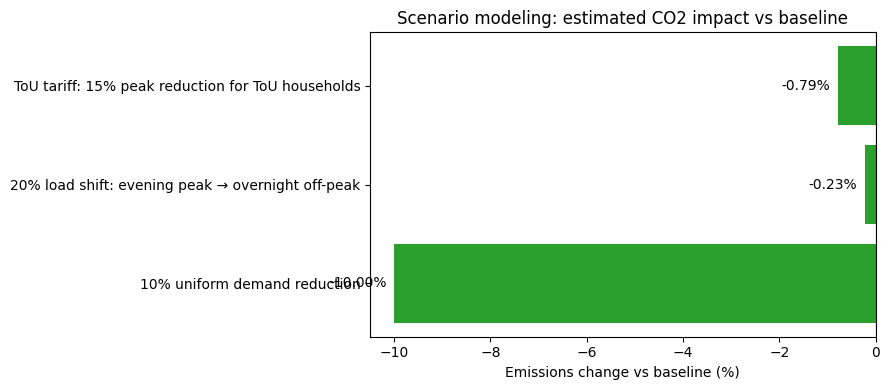

In [ ]:
summary = pd.DataFrame([
    {"Scenario": r["scenario"], "Total kgCO2": r["total_kg"], "Change (%)": r["delta_pct"]}
    for r in results
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2ca02c" if d < 0 else "#d62728" for d in summary["Change (%)"]]
bars = ax.barh(summary["Scenario"], summary["Change (%)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Emissions change vs baseline (%)")
ax.set_title("Scenario modeling: estimated CO2 impact vs baseline")
for bar, val in zip(bars, summary["Change (%)"]):
    offset = -0.15 if val < 0 else 0.05
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}%", va="center",
            ha="right" if val < 0 else "left", fontsize=10)
plt.tight_layout()
plt.show()

Hourly emissions and carbon intensity profiles

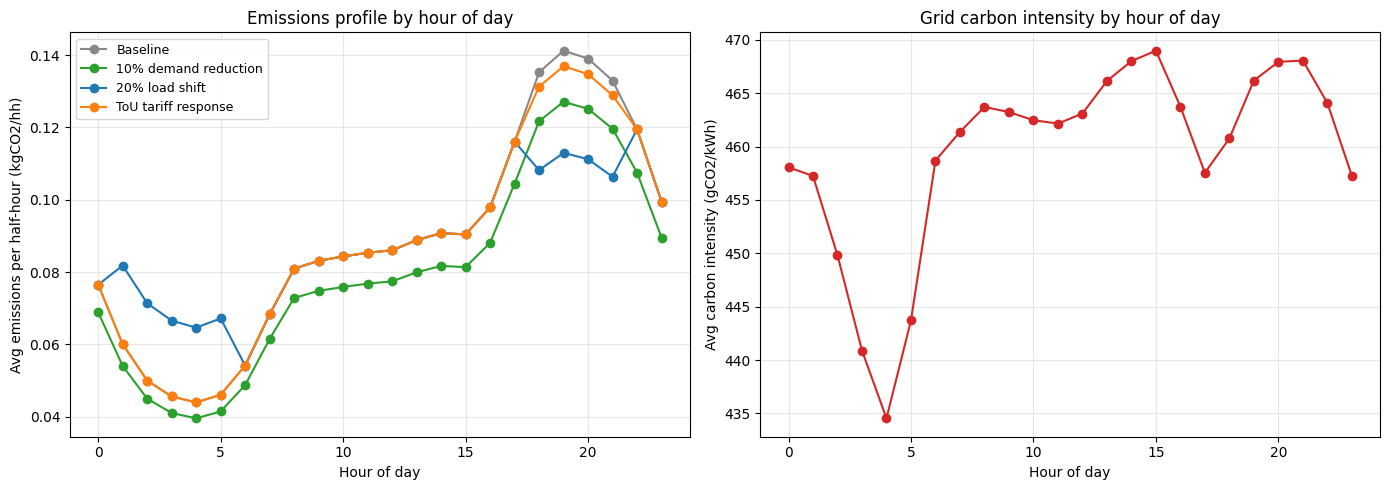

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average emissions per half-hour by hour of day, per scenario
scenarios = [
    ("Baseline",              "y_pred",    "#888888"),
    ("10% demand reduction",  "y_pred_s1", "#2ca02c"),
    ("20% load shift",        "y_pred_s2", "#1f77b4"),
    ("ToU tariff response",   "y_pred_s3", "#ff7f0e"),
]
for label, col, color in scenarios:
    hourly = df_test.groupby("hour").apply(
        lambda g: (g[col] * g["CARBON_INTENSITY"] / 1000).mean()
    )
    axes[0].plot(hourly.index, hourly.values, marker="o", lw=1.5,
                 label=label, color=color)

axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Avg emissions per half-hour (kgCO2/hh)")
axes[0].set_title("Emissions profile by hour of day")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: average grid carbon intensity by hour — explains WHY load shifting works
ci_hourly = df_test.groupby("hour")["CARBON_INTENSITY"].mean()
axes[1].plot(ci_hourly.index, ci_hourly.values, color="#d62728", marker="o", lw=1.5)
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Avg carbon intensity (gCO2/kWh)")
axes[1].set_title("Grid carbon intensity by hour of day")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Monthly Breakdown

month_label     baseline   load_shift   tou_tariff   demand_red
    2013-11 29456.322744 29374.474347 29235.379014 26510.689778
    2013-12 58571.758663 58396.181552 58115.413149 52714.581423
    2014-01 58341.343271 58226.259564 57866.409439 52507.207576
    2014-02 47975.493104 47901.266268 47592.695786 43177.942665


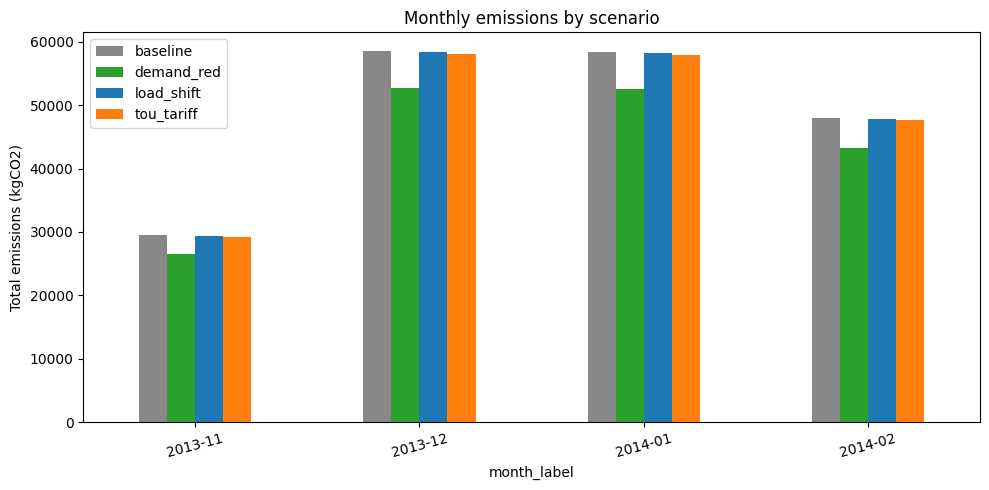

In [ ]:
df_test["month_label"] = df_test["tstp"].dt.to_period("M").astype(str)

monthly = df_test.groupby("month_label").apply(lambda g: pd.Series({
    "baseline":    (g["y_pred"]    * g["CARBON_INTENSITY"] / 1000).sum(),
    "load_shift":  (g["y_pred_s2"] * g["CARBON_INTENSITY"] / 1000).sum(),
    "tou_tariff":  (g["y_pred_s3"] * g["CARBON_INTENSITY"] / 1000).sum(),
    "demand_red":  (g["y_pred_s1"] * g["CARBON_INTENSITY"] / 1000).sum(),
})).reset_index()

print(monthly.to_string(index=False))

monthly.plot(x="month_label", y=["baseline", "demand_red", "load_shift", "tou_tariff"],
             kind="bar", figsize=(10, 5), color=["#888", "#2ca02c", "#1f77b4", "#ff7f0e"])
plt.ylabel("Total emissions (kgCO2)")
plt.title("Monthly emissions by scenario")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

per-household annualized estimate

In [ ]:
# Extrapolate test period results to a full year
days_in_test = 104
scale_to_year = 365 / days_in_test

print("=== Annualized estimates (per household) ===")
for r in results:
    annual_saving_per_hh = abs(r["delta_kg"]) / 460 * scale_to_year
    print(f"{r['scenario'][:45]:<45} → {annual_saving_per_hh:,.1f} kgCO2/household/year saved")

=== Annualized estimates (per household) ===
10% uniform demand reduction                  → 148.3 kgCO2/household/year saved
20% load shift: evening peak → overnight off- → 3.4 kgCO2/household/year saved
ToU tariff: 15% peak reduction for ToU househ → 11.7 kgCO2/household/year saved


comparing against City of London policy targets

In [ ]:
# GLA target: 40% reduction in building heat demand by 2030
TARGET_PCT = 40.0
baseline_annual_per_hh = (total_baseline / 460) * (365 / 104)

print(f"Baseline annual emissions per household: {baseline_annual_per_hh:.1f} kgCO2/year")
print(f"GLA 40% building demand reduction target: {baseline_annual_per_hh * 0.40:.1f} kgCO2/year needed")
print()
for r in results:
    annual_saving = abs(r["delta_kg"]) / 460 * (365 / 104)
    pct_of_target = 100 * annual_saving / (baseline_annual_per_hh * 0.40)
    print(f"{r['scenario'][:50]:<50} covers {pct_of_target:.1f}% of the target")

Baseline annual emissions per household: 1482.8 kgCO2/year
GLA 40% building demand reduction target: 593.1 kgCO2/year needed

10% uniform demand reduction                       covers 25.0% of the target
20% load shift: evening peak → overnight off-peak  covers 0.6% of the target
ToU tariff: 15% peak reduction for ToU households  covers 2.0% of the target


In [ ]:
scenarios_demand = {}

# Observed baseline
scenarios_demand["baseline_observed"] = df_test["y_pred"].copy()

# Cold winter -2C: temperature, apparentTemperature, dewPoint reduced by 2
# HDD/CDD recomputed, then re-predict with LightGBM
X_cold2 = X_test.copy()
X_cold2["temperature"]         -= 2
X_cold2["apparentTemperature"] -= 2
X_cold2["dewPoint"]            -= 2
X_cold2["hdd"] = (15.5 - X_cold2["temperature"]).clip(lower=0)
X_cold2["cdd"] = (X_cold2["temperature"] - 22.0).clip(lower=0)
scenarios_demand["cold_winter_minus2C"] = np.clip(
    lgb_model.predict(X_cold2, num_iteration=feat_meta["best_iteration"]), 0, None
).astype("float32")

# Severe cold -3C
X_cold3 = X_test.copy()
X_cold3["temperature"]         -= 3
X_cold3["apparentTemperature"] -= 3
X_cold3["dewPoint"]            -= 3
X_cold3["hdd"] = (15.5 - X_cold3["temperature"]).clip(lower=0)
X_cold3["cdd"] = (X_cold3["temperature"] - 22.0).clip(lower=0)
scenarios_demand["severe_cold_minus3C"] = np.clip(
    lgb_model.predict(X_cold3, num_iteration=feat_meta["best_iteration"]), 0, None
).astype("float32")

# Retrofit 10%: reduce lag and rolling proxies by 10%
X_retro10 = X_test.copy()
for col in ["lag_1", "lag_2", "lag_48", "lag_336",
            "rolling_mean_1d", "rolling_std_1d",
            "rolling_mean_7d", "rolling_std_7d",
            "household_train_mean"]:
    X_retro10[col] *= 0.90
scenarios_demand["retrofit_10pct"] = np.clip(
    lgb_model.predict(X_retro10, num_iteration=feat_meta["best_iteration"]), 0, None
).astype("float32")

# Cold + retrofit 10%
X_cold_retro = X_cold2.copy()
for col in ["lag_1", "lag_2", "lag_48", "lag_336",
            "rolling_mean_1d", "rolling_std_1d",
            "rolling_mean_7d", "rolling_std_7d",
            "household_train_mean"]:
    X_cold_retro[col] *= 0.90
scenarios_demand["cold_minus2C_retrofit_10pct"] = np.clip(
    lgb_model.predict(X_cold_retro, num_iteration=feat_meta["best_iteration"]), 0, None
).astype("float32")

# Cold + retrofit + ToU flexibility
# Same as above but apply 7% peak reduction + 50% overnight rebound as behavioral overlay
PEAK_HOURS   = list(range(16, 20))   # 4 PM - 8 PM
OFFPEAK_HOURS = list(range(0, 6))
y_cold_retro_flex = scenarios_demand["cold_minus2C_retrofit_10pct"].copy()
peak_mask    = df_test["hour"].isin(PEAK_HOURS)
offpeak_mask = df_test["hour"].isin(OFFPEAK_HOURS)
shifted = y_cold_retro_flex[peak_mask.values] * 0.07
y_cold_retro_flex[peak_mask.values]    -= shifted
y_cold_retro_flex[offpeak_mask.values] += (shifted.sum() * 0.50) / offpeak_mask.sum()
scenarios_demand["cold_retrofit_tou_flex"] = y_cold_retro_flex

# Strong policy package: -2C, 15% retrofit, 10% peak reduction, 50% overnight rebound
X_strong = X_cold2.copy()
for col in ["lag_1", "lag_2", "lag_48", "lag_336",
            "rolling_mean_1d", "rolling_std_1d",
            "rolling_mean_7d", "rolling_std_7d",
            "household_train_mean"]:
    X_strong[col] *= 0.85
y_strong = np.clip(
    lgb_model.predict(X_strong, num_iteration=feat_meta["best_iteration"]), 0, None
).astype("float32")
shifted_strong = y_strong[peak_mask.values] * 0.10
y_strong[peak_mask.values]    -= shifted_strong
y_strong[offpeak_mask.values] += (shifted_strong.sum() * 0.50) / offpeak_mask.sum()
scenarios_demand["strong_policy_package"] = y_strong

print("Scenarios built:", list(scenarios_demand.keys()))

Scenarios built: ['baseline_observed', 'cold_winter_minus2C', 'severe_cold_minus3C', 'retrofit_10pct', 'cold_minus2C_retrofit_10pct', 'cold_retrofit_tou_flex', 'strong_policy_package']


In [ ]:
results_emissions = []

for scenario_name, y_pred_s in scenarios_demand.items():
    emissions = y_pred_s * df_test["CARBON_INTENSITY"].values / 1000
    total_demand_kwh  = y_pred_s.sum()
    total_emit_kg     = emissions.sum()
    baseline_emit_kg  = (scenarios_demand["baseline_observed"] *
                         df_test["CARBON_INTENSITY"].values / 1000).sum()
    baseline_kwh      = scenarios_demand["baseline_observed"].sum()

    results_emissions.append({
        "scenario":          scenario_name,
        "total_kWh":         total_demand_kwh,
        "delta_kWh_pct":     100 * (total_demand_kwh - baseline_kwh) / baseline_kwh,
        "total_kgCO2":       total_emit_kg,
        "delta_kgCO2":       total_emit_kg - baseline_emit_kg,
        "delta_kgCO2_pct":   100 * (total_emit_kg - baseline_emit_kg) / baseline_emit_kg,
    })

df_results = pd.DataFrame(results_emissions)
print(df_results.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

                   scenario  total_kWh  delta_kWh_pct  total_kgCO2  delta_kgCO2  delta_kgCO2_pct
          baseline_observed 421,261.31           0.00   194,344.92         0.00             0.00
        cold_winter_minus2C 422,143.25           0.21   194,756.08       411.17             0.21
        severe_cold_minus3C 422,552.78           0.31   194,945.93       601.01             0.31
             retrofit_10pct 379,013.69         -10.03   174,847.95   -19,496.97           -10.03
cold_minus2C_retrofit_10pct 379,684.53          -9.87   175,161.16   -19,183.76            -9.87
     cold_retrofit_tou_flex 376,598.41         -10.60   173,691.46   -20,653.46           -10.63
      strong_policy_package 354,525.19         -15.84   163,486.83   -30,858.08           -15.88


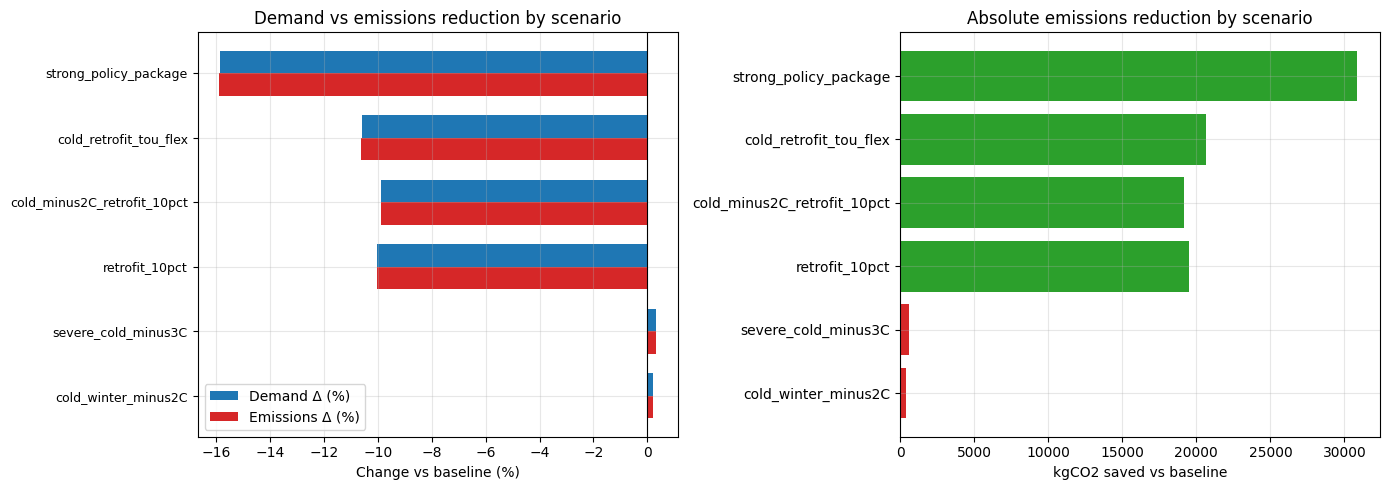

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios_plot = df_results[df_results["scenario"] != "baseline_observed"]
colors = ["#2ca02c" if v < 0 else "#d62728" for v in scenarios_plot["delta_kgCO2_pct"]]

# Left: kWh vs kgCO2 reduction side by side
x = np.arange(len(scenarios_plot))
w = 0.35
axes[0].barh(x + w/2, scenarios_plot["delta_kWh_pct"],  w, label="Demand Δ (%)",  color="#1f77b4")
axes[0].barh(x - w/2, scenarios_plot["delta_kgCO2_pct"], w, label="Emissions Δ (%)", color="#d62728")
axes[0].set_yticks(x)
axes[0].set_yticklabels(scenarios_plot["scenario"], fontsize=9)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Change vs baseline (%)")
axes[0].set_title("Demand vs emissions reduction by scenario")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: absolute kgCO2 saved vs baseline
baseline_emit = df_results.loc[df_results["scenario"]=="baseline_observed", "total_kgCO2"].values[0]
axes[1].barh(scenarios_plot["scenario"],
             abs(scenarios_plot["delta_kgCO2"]),
             color=colors)
axes[1].set_xlabel("kgCO2 saved vs baseline")
axes[1].set_title("Absolute emissions reduction by scenario")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

print("=== Demand reduction vs Emissions reduction comparison ===\n")
print(f"{'Scenario':<35} {'Demand Δ%':>10} {'Emissions Δ%':>13} {'Divergence':>11}")
print("-" * 72)

for _, row in df_results.iterrows():
    if row["scenario"] == "baseline_observed":
        continue
    divergence = row["delta_kgCO2_pct"] - row["delta_kWh_pct"]
    print(f"{row['scenario']:<35} {row['delta_kWh_pct']:>10.2f}% "
          f"{row['delta_kgCO2_pct']:>12.2f}% {divergence:>+11.3f}%")

print("\nPositive divergence = emissions fall MORE than demand (load shifted to cleaner hours)")
print("Negative divergence = emissions fall LESS than demand (load shifted to dirtier hours)")

=== Demand reduction vs Emissions reduction comparison ===

Scenario                             Demand Δ%  Emissions Δ%  Divergence
------------------------------------------------------------------------
cold_winter_minus2C                       0.21%         0.21%      +0.002%
severe_cold_minus3C                       0.31%         0.31%      +0.003%
retrofit_10pct                          -10.03%       -10.03%      -0.003%
cold_minus2C_retrofit_10pct              -9.87%        -9.87%      -0.001%
cold_retrofit_tou_flex                  -10.60%       -10.63%      -0.025%
strong_policy_package                   -15.84%       -15.88%      -0.036%

Positive divergence = emissions fall MORE than demand (load shifted to cleaner hours)
Negative divergence = emissions fall LESS than demand (load shifted to dirtier hours)
